# MWE 35 - Trabecular bone microarchitecture from a RAW segmentation

This notebook analyzes:

- `examples/data/trabecular-image/Trabecular_300_cubo_0_poro_1_osso_2086nm.raw`

The cropped image is derived from the micro-CT trabecular-bone analysis in:

- Marques et al. (2026), *Aluminum impairs cellular ultrastructure and bone
  microarchitecture in newborn rats*. Frontiers in Imaging 5:1725794.
  <https://doi.org/10.3389/fimag.2026.1725794>

The filename is interpreted as Portuguese phase metadata:

- `0_poro`: marrow/pore space is stored as `0`
- `1_osso`: bone is stored as `1`
- `2086nm`: isotropic voxel size is `2086 nm = 2.086 um`

The byte count does **not** match a `300 x 300 x 300` uint8 cube. It matches
`350 x 350 x 349` uint8 voxels, so that shape is used below. Because this RAW
file has no sidecar header, the axis order remains a data-provenance
assumption; scalar morphometry is unaffected by axis permutation, but
directional chord-length or anisotropy interpretation is not.

Bone-focused questions that are interesting here:

- What is the bone volume fraction, `BV/TV`, of this specimen?
- Is the bone fraction spatially homogeneous, or does it drift across slices?
- What are simple trabecular thickness and spacing proxies?
- Are bone and marrow phases connected across the region of interest?
- Are axis-aligned chord lengths similar in all directions, or is there
  directional fabric/anisotropy worth following up?
- As an optional `voids` extension, what would the marrow-space pore network
  and transport look like if the marrow phase is treated as the conducting
  pore space?

## References for terminology

The measurements below use standard bone morphometry language, but several
estimates are intentionally marked as proxies. In particular, the
plate-model relations from surface area are not the same as a
model-independent local-thickness analysis.

- Parfitt et al. (1987), *Bone histomorphometry: standardization of
  nomenclature, symbols, and units*. <https://doi.org/10.1002/jbmr.5650020617>
- Bouxsein et al. (2010), *Guidelines for assessment of bone microstructure
  in rodents using micro-computed tomography*. <https://doi.org/10.1002/jbmr.141>
- Hildebrand and Ruegsegger (1997), *A new method for the model-independent
  assessment of thickness in three-dimensional images*.
  <https://doi.org/10.1046/j.1365-2818.1997.1340694.x>

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage as ndi
from skimage import measure

from voids.image import local_thickness_analysis
from voids.paths import data_path, project_root

In [2]:
# User-editable inputs
raw_relpath = Path("trabecular-image") / "Trabecular_300_cubo_0_poro_1_osso_2086nm.raw"
raw_dtype = np.uint8
raw_shape = (350, 350, 349)
raw_order = "C"

bone_value = 1
marrow_value = 0

voxel_size_nm = 2086.0
voxel_size_um = voxel_size_nm * 1.0e-3
voxel_size_mm = voxel_size_um * 1.0e-3

axis_labels = ("x", "y", "z")

paper_voi_diameter_mm = 2.0
paper_voi_height_mm = 2.0
paper_control_bvtv_pct = 24.1
paper_aluminum_bvtv_pct = 13.7
paper_control_tb_th_um = 19.3
paper_aluminum_tb_th_um = 16.5
paper_control_tb_sp_um = 77.1
paper_aluminum_tb_sp_um = 148.3
paper_control_tb_n_per_um = 0.0104
paper_aluminum_tb_n_per_um = 0.0061

# Full-volume distance maps are useful but consume a few hundred MB while they
# are being computed. Disable this for a very lightweight first pass.
compute_distance_maps = True

# Local thickness is closer to BoneJ trabecular thickness/separation than the
# surface-based plate-model proxy. The `dt` method is practical for this crop;
# use `imj` for a closer ImageJ-style sphere insertion at substantially higher
# runtime.
compute_local_thickness_maps = True
local_thickness_method = "dt"
local_thickness_sizes = 32
local_thickness_smooth = True
local_thickness_approx = False

# Chord-length distributions are computed on every axis-aligned line by default.
# Increase this stride to 2, 4, ... for a faster approximate distribution.
chord_line_stride = 1

# Static PyVista cutaway render. This is visualization-only; all morphometry
# below is still computed on the full-resolution segmentation.
render_pyvista_cutaway = True
pyvista_cutaway_stride = 2
pyvista_cutaway_plane_normal_axis = "y"
pyvista_cutaway_transparent_side = "upper"
pyvista_cutaway_transparent_opacity = 0.03
pyvista_cutaway_solid_opacity = 1.0
pyvista_cutaway_window_size = (1600, 1200)
pyvista_cutaway_png = project_root() / "tmp" / "trabecular_bone_cutaway.png"

# Optional, expensive extension. Leave disabled unless the goal is specifically
# to treat marrow space as a pore network for transport analysis.
run_marrow_pore_network = False

In [3]:
raw_path = data_path() / raw_relpath


def raw_shape_candidates(
    path: Path,
    *,
    dtype: np.dtype,
    min_side: int = 250,
    max_side: int = 500,
) -> list[tuple[int, int, int]]:
    """Return plausible 3D uint-volume shapes from a raw file byte count."""
    itemsize = np.dtype(dtype).itemsize
    file_size = path.stat().st_size
    if file_size % itemsize:
        raise ValueError(
            f"{path.name} has {file_size} bytes, not divisible by {itemsize}."
        )

    voxel_count = file_size // itemsize
    candidates: list[tuple[int, int, int]] = []
    for n0 in range(min_side, max_side + 1):
        if voxel_count % n0:
            continue
        rem = voxel_count // n0
        for n1 in range(min_side, max_side + 1):
            if rem % n1:
                continue
            n2 = rem // n1
            if min_side <= n2 <= max_side:
                candidates.append((n0, n1, int(n2)))

    return sorted(set(candidates), key=lambda shape: (max(shape) - min(shape), shape))


if not raw_path.exists():
    raise FileNotFoundError(
        f"Missing trabecular RAW volume at {raw_path}. "
        "Run from the repository root or set VOIDS_DATA_PATH."
    )

shape_candidates = raw_shape_candidates(raw_path, dtype=np.dtype(raw_dtype))
expected_voxels = int(np.prod(np.asarray(raw_shape, dtype=np.int64)))
actual_voxels = raw_path.stat().st_size // np.dtype(raw_dtype).itemsize
if expected_voxels != actual_voxels:
    raise ValueError(
        f"Configured shape {raw_shape} requires {expected_voxels:,} voxels, "
        f"but {raw_path.name} stores {actual_voxels:,}. "
        f"Plausible shapes include: {shape_candidates[:8]}"
    )

raw_image = np.memmap(
    raw_path,
    dtype=raw_dtype,
    mode="r",
    shape=raw_shape,
    order=raw_order,
)
values, counts = np.unique(np.asarray(raw_image), return_counts=True)
value_table = pd.DataFrame(
    {
        "raw_value": values.astype(int),
        "voxel_count": counts.astype(np.int64),
        "fraction": counts / counts.sum(),
    }
)

print(f"RAW path: {raw_path}")
print(f"File size: {raw_path.stat().st_size:,} bytes")
print(f"Shape candidates from byte count: {shape_candidates[:8]}")
print(f"Using shape: {raw_shape}")
print(f"dtype: {np.dtype(raw_dtype)}")
print(f"Memory order: {raw_order}")
print(f"Voxel size: {voxel_size_um:.3f} um")
print()
print(value_table.to_string(index=False))

if set(values.tolist()) - {marrow_value, bone_value}:
    raise ValueError(
        "This notebook expects a binary segmentation with only the configured "
        f"marrow/bone values {marrow_value!r}/{bone_value!r}."
    )

bone = np.asarray(raw_image == bone_value, dtype=bool)
marrow = np.asarray(raw_image == marrow_value, dtype=bool)

RAW path: /Users/dtvolpatto/Work/voids/examples/data/trabecular-image/Trabecular_300_cubo_0_poro_1_osso_2086nm.raw
File size: 42,752,500 bytes
Shape candidates from byte count: [(349, 350, 350), (350, 349, 350), (350, 350, 349), (250, 349, 490), (250, 490, 349), (349, 250, 490), (349, 490, 250), (490, 250, 349)]
Using shape: (350, 350, 349)
dtype: uint8
Memory order: C
Voxel size: 2.086 um

 raw_value  voxel_count  fraction
         0     35170436  0.822652
         1      7582064  0.177348


## Phase convention and physical size

`voids` image workflows usually treat `1` as void/pore. For bone
morphometry, this notebook keeps the biological convention explicit:

- `bone == True` means mineralized trabecular tissue.
- `marrow == True` means the intertrabecular pore/marrow space.

In [4]:
shape_array = np.asarray(raw_shape, dtype=float)
lengths_mm = shape_array * voxel_size_mm
voxel_volume_mm3 = voxel_size_mm**3
total_volume_mm3 = float(np.prod(lengths_mm))
bone_volume_mm3 = float(np.count_nonzero(bone) * voxel_volume_mm3)
marrow_volume_mm3 = float(np.count_nonzero(marrow) * voxel_volume_mm3)

bvtv = bone_volume_mm3 / total_volume_mm3
marrow_fraction = marrow_volume_mm3 / total_volume_mm3

volume_summary = pd.DataFrame(
    [
        {
            "metric": "ROI size x",
            "value": lengths_mm[0],
            "units": "mm",
        },
        {
            "metric": "ROI size y",
            "value": lengths_mm[1],
            "units": "mm",
        },
        {
            "metric": "ROI size z",
            "value": lengths_mm[2],
            "units": "mm",
        },
        {
            "metric": "Tissue volume TV",
            "value": total_volume_mm3,
            "units": "mm^3",
        },
        {
            "metric": "Bone volume BV",
            "value": bone_volume_mm3,
            "units": "mm^3",
        },
        {
            "metric": "Marrow volume",
            "value": marrow_volume_mm3,
            "units": "mm^3",
        },
        {
            "metric": "Bone volume fraction BV/TV",
            "value": bvtv,
            "units": "-",
        },
        {
            "metric": "Marrow/pore fraction",
            "value": marrow_fraction,
            "units": "-",
        },
    ]
)
volume_summary

,metric,value,units
0,ROI size x,0.730100,mm
1,ROI size y,0.730100,mm
2,ROI size z,0.728014,mm
3,Tissue volume TV,0.388065,mm^3
4,Bone volume BV,0.068822,mm^3
5,Marrow volume,0.319242,mm^3
6,Bone volume fraction BV/TV,0.177348,-
7,Marrow/pore fraction,0.822652,-


## Relation to the published VOI

The published trabecular analysis used a cylindrical VOI of `2 mm` diameter by
`2 mm` height. This cropped cuboid is much smaller, so the comparisons below
are sanity checks and context, not reproduction of the paper's group-level
table. The crop also may come from a localized depth where both groups can
have similar `BV/TV`, as shown by the paper's slice-wise profile.

In [5]:
paper_voi_volume_mm3 = float(
    np.pi * (paper_voi_diameter_mm / 2.0) ** 2 * paper_voi_height_mm
)
crop_fraction_of_paper_voi = total_volume_mm3 / paper_voi_volume_mm3

paper_context = pd.DataFrame(
    [
        {
            "quantity": "Published cylindrical trabecular VOI",
            "value": paper_voi_volume_mm3,
            "units": "mm^3",
        },
        {
            "quantity": "Current cropped cuboid volume",
            "value": total_volume_mm3,
            "units": "mm^3",
        },
        {
            "quantity": "Crop / published VOI volume",
            "value": crop_fraction_of_paper_voi,
            "units": "-",
        },
        {
            "quantity": "Current crop BV/TV",
            "value": 100.0 * bvtv,
            "units": "%",
        },
        {
            "quantity": "Paper Control mean BV/TV",
            "value": paper_control_bvtv_pct,
            "units": "%",
        },
        {
            "quantity": "Paper Aluminum mean BV/TV",
            "value": paper_aluminum_bvtv_pct,
            "units": "%",
        },
    ]
)
paper_context

,quantity,value,units
0,Published cylindrical trabecular VOI,6.283185,mm^3
1,Current cropped cuboid volume,0.388065,mm^3
2,Crop / published VOI volume,0.061762,-
3,Current crop BV/TV,17.734785,%
4,Paper Control mean BV/TV,24.100000,%
5,Paper Aluminum mean BV/TV,13.700000,%


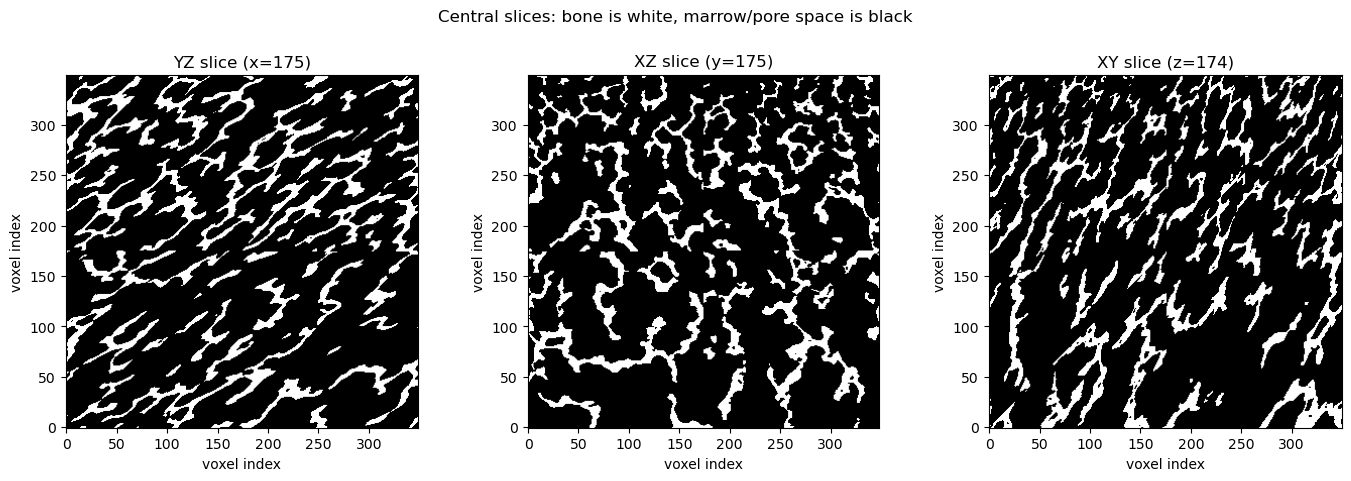

In [6]:
midpoints = tuple(n // 2 for n in raw_shape)
slice_specs = (
    ("YZ", 0, midpoints[0], bone[midpoints[0], :, :]),
    ("XZ", 1, midpoints[1], bone[:, midpoints[1], :]),
    ("XY", 2, midpoints[2], bone[:, :, midpoints[2]]),
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (plane, axis, index, image2d) in zip(axes, slice_specs):
    ax.imshow(image2d, cmap="gray", origin="lower", vmin=0, vmax=1)
    ax.set_title(f"{plane} slice ({axis_labels[axis]}={index})")
    ax.set_xlabel("voxel index")
    ax.set_ylabel("voxel index")

fig.suptitle("Central slices: bone is white, marrow/pore space is black", y=1.03)
fig.tight_layout()

## Static 3D bone cutaway

The rendering below builds a voxel-derived PyVista mesh of the bone phase,
splits it with a vertical plane through the center of the ROI, and saves a
static off-screen screenshot. The side before the plane is drawn nearly
transparent, while the side after the plane is drawn solid. The default plane
is normal to `y`, so it contains the `x` and `z` directions.

The full-resolution binary image is downsampled only for plotting; the
physical bounding box is preserved so the cut plane remains at the sample
center in micrometers.

This is a qualitative visualization, not an additional morphometric
estimator. The same phase-convention and axis-order assumptions stated above
still apply.

{'screenshot_path': '/Users/dtvolpatto/Work/voids/tmp/trabecular_bone_cutaway.png',
 'original_shape_voxels': (350, 350, 349),
 'rendered_shape_voxels': (175, 175, 175),
 'spacing_um': (np.float64(4.172), np.float64(4.172), np.float64(4.16008)),
 'plane_normal_axis': 'y',
 'plane_axes': ('x', 'z'),
 'cut_origin_um': 365.04999999999995,
 'transparent_side': 'upper',
 'solid_side': 'lower',
 'transparent_opacity': 0.03,
 'solid_opacity': 1.0,
 'transparent_bone_cells': 496605,
 'solid_bone_cells': 458731}

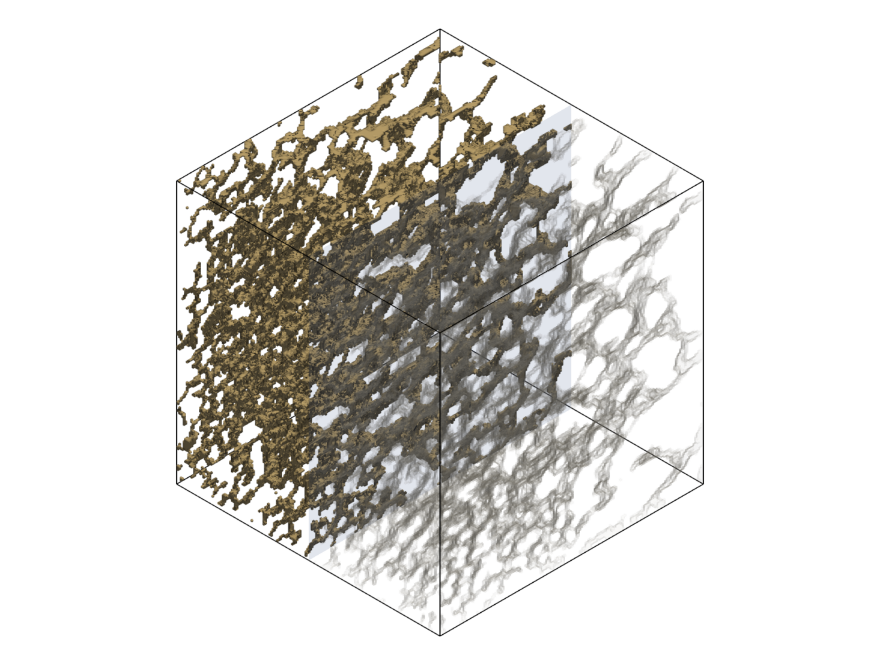

In [7]:
def render_bone_cutaway_pyvista(
    bone_mask: np.ndarray,
    *,
    voxel_size_um: float,
    stride: int,
    plane_normal_axis: str,
    transparent_side: str,
    transparent_opacity: float,
    solid_opacity: float,
    screenshot_path: Path,
    window_size: tuple[int, int],
) -> dict[str, object]:
    """Render a static PyVista split-plane view of the segmented bone phase."""
    if stride < 1:
        raise ValueError("stride must be a positive integer.")
    if plane_normal_axis not in axis_labels:
        raise ValueError(f"plane_normal_axis must be one of {axis_labels!r}.")
    if transparent_side not in {"lower", "upper"}:
        raise ValueError("transparent_side must be either 'lower' or 'upper'.")
    if not 0.0 <= transparent_opacity <= 1.0:
        raise ValueError("transparent_opacity must be between 0 and 1.")
    if not 0.0 <= solid_opacity <= 1.0:
        raise ValueError("solid_opacity must be between 0 and 1.")

    import pyvista as pv

    sampled = np.asarray(bone_mask, dtype=bool)[::stride, ::stride, ::stride]
    sampled_shape = np.asarray(sampled.shape, dtype=int)
    physical_lengths_um = np.asarray(bone_mask.shape, dtype=float) * voxel_size_um
    spacing_um = tuple((physical_lengths_um / sampled_shape).astype(float))

    grid = pv.ImageData(
        dimensions=tuple((sampled_shape + 1).astype(int)),
        spacing=spacing_um,
        origin=(0.0, 0.0, 0.0),
    )
    grid.cell_data["bone"] = sampled.astype(np.uint8).ravel(order="F")

    bone_cells = grid.threshold(0.5, scalars="bone")
    if bone_cells.n_cells == 0:
        raise ValueError("The sampled bone mask contains no bone voxels to render.")

    cut_axis_index = axis_labels.index(plane_normal_axis)
    cut_normal = np.zeros(3, dtype=float)
    cut_normal[cut_axis_index] = 1.0
    cut_origin_um = 0.5 * physical_lengths_um

    def clip_side(side: str):
        return bone_cells.clip(
            normal=tuple(cut_normal),
            origin=tuple(cut_origin_um),
            invert=side == "lower",
        )

    solid_side = "lower" if transparent_side == "upper" else "upper"
    transparent_cells = clip_side(transparent_side)
    solid_cells = clip_side(solid_side)
    transparent_surface = transparent_cells.extract_surface(
        algorithm="dataset_surface"
    ).triangulate()
    solid_surface = solid_cells.extract_surface(
        algorithm="dataset_surface"
    ).triangulate()

    plane_axes = [axis for axis in range(3) if axis != cut_axis_index]
    cut_plane = pv.Plane(
        center=tuple(cut_origin_um),
        direction=tuple(cut_normal),
        i_size=float(physical_lengths_um[plane_axes[0]]),
        j_size=float(physical_lengths_um[plane_axes[1]]),
    )

    screenshot_path.parent.mkdir(parents=True, exist_ok=True)
    plotter = pv.Plotter(off_screen=True, window_size=window_size)
    plotter.set_background("white")
    plotter.add_mesh(
        transparent_surface,
        color="#d8d2c3",
        opacity=transparent_opacity,
        smooth_shading=True,
        specular=0.08,
    )
    plotter.add_mesh(
        solid_surface,
        color="#c9b17d",
        opacity=solid_opacity,
        smooth_shading=True,
        specular=0.12,
    )
    plotter.add_mesh(cut_plane, color="#2563eb", opacity=0.12)
    plotter.add_mesh(grid.outline(), color="black", line_width=2)
    plotter.enable_parallel_projection()
    plotter.view_isometric()
    plotter.camera.zoom(1)
    plotter.screenshot(str(screenshot_path), scale=1)
    plotter.close()

    return {
        "screenshot_path": str(screenshot_path),
        "original_shape_voxels": tuple(int(v) for v in bone_mask.shape),
        "rendered_shape_voxels": tuple(int(v) for v in sampled_shape),
        "spacing_um": spacing_um,
        "plane_normal_axis": plane_normal_axis,
        "plane_axes": tuple(axis_labels[axis] for axis in plane_axes),
        "cut_origin_um": float(cut_origin_um[cut_axis_index]),
        "transparent_side": transparent_side,
        "solid_side": solid_side,
        "transparent_opacity": transparent_opacity,
        "solid_opacity": solid_opacity,
        "transparent_bone_cells": int(transparent_cells.n_cells),
        "solid_bone_cells": int(solid_cells.n_cells),
    }


pyvista_cutaway_metadata: dict[str, object] = {}
if render_pyvista_cutaway:
    pyvista_cutaway_metadata = render_bone_cutaway_pyvista(
        bone,
        voxel_size_um=voxel_size_um,
        stride=pyvista_cutaway_stride,
        plane_normal_axis=pyvista_cutaway_plane_normal_axis,
        transparent_side=pyvista_cutaway_transparent_side,
        transparent_opacity=pyvista_cutaway_transparent_opacity,
        solid_opacity=pyvista_cutaway_solid_opacity,
        screenshot_path=pyvista_cutaway_png,
        window_size=pyvista_cutaway_window_size,
    )

    cutaway_image = plt.imread(pyvista_cutaway_png)
    fig, ax = plt.subplots(figsize=(9, 6.75))
    ax.imshow(cutaway_image)
    ax.axis("off")
    fig.tight_layout()

pyvista_cutaway_metadata

## Projected bone thickness

A binary maximum-intensity projection is not very informative for this sample:
almost every projected ray intersects bone somewhere, so the image saturates
to white. The maps below instead show the line-integrated bone thickness along
each axis.

,projection_axis,mean_projected_bone_thickness_um,p10_projected_bone_thickness_um,p90_projected_bone_thickness_um,max_projected_bone_thickness_um
0,x,129.481666,70.924,193.998,348.362
1,y,129.481666,85.526,173.138,298.298
2,z,129.111718,77.182,185.654,292.040


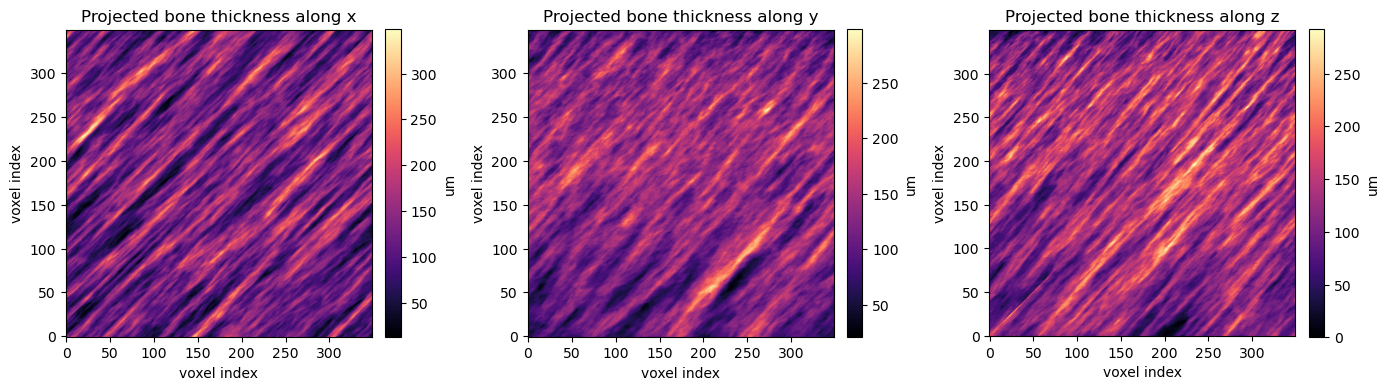

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
projection_records: list[dict[str, float | str]] = []
for axis, ax in enumerate(axes):
    projected_thickness_um = np.sum(bone, axis=axis) * voxel_size_um
    projection_records.append(
        {
            "projection_axis": axis_labels[axis],
            "mean_projected_bone_thickness_um": float(np.mean(projected_thickness_um)),
            "p10_projected_bone_thickness_um": float(
                np.percentile(projected_thickness_um, 10.0)
            ),
            "p90_projected_bone_thickness_um": float(
                np.percentile(projected_thickness_um, 90.0)
            ),
            "max_projected_bone_thickness_um": float(np.max(projected_thickness_um)),
        }
    )
    image = ax.imshow(projected_thickness_um, cmap="magma", origin="lower")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="um")
    ax.set_title(f"Projected bone thickness along {axis_labels[axis]}")
    ax.set_xlabel("voxel index")
    ax.set_ylabel("voxel index")

fig.tight_layout()

projection_summary = pd.DataFrame(projection_records)
projection_summary

## Slice-wise bone fraction

These curves are a quick heterogeneity check. A strong monotonic drift can
indicate that the ROI cuts through a structural gradient, damage, or a
thresholding/registration artifact.

In [9]:
slice_records: list[dict[str, float | str | int]] = []
slice_bvtv_by_axis: dict[str, np.ndarray] = {}
for axis, label in enumerate(axis_labels):
    other_axes = tuple(i for i in range(3) if i != axis)
    profile = np.mean(bone, axis=other_axes)
    slice_bvtv_by_axis[label] = profile
    for idx, value in enumerate(profile):
        slice_records.append(
            {
                "axis": label,
                "slice": idx,
                "position_mm": idx * voxel_size_mm,
                "BV/TV": float(value),
            }
        )

slice_bvtv = pd.DataFrame(slice_records)
slice_summary = (
    slice_bvtv.groupby("axis")["BV/TV"].agg(["mean", "std", "min", "max"]).reset_index()
)
slice_summary["coefficient_of_variation"] = slice_summary["std"] / slice_summary["mean"]
slice_summary

,axis,mean,std,min,max,coefficient_of_variation
0,x,0.177348,0.019926,0.124806,0.204732,0.112357
1,y,0.177348,0.011950,0.152280,0.197290,0.067384
2,z,0.177348,0.007507,0.162947,0.194751,0.042328


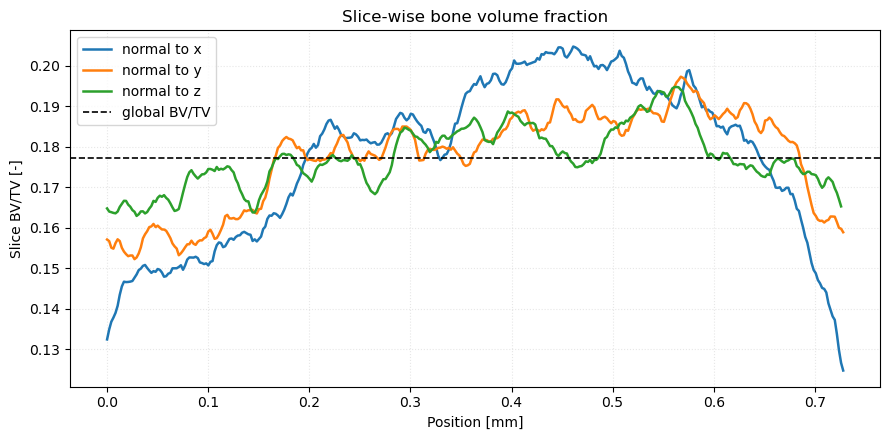

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for label in axis_labels:
    profile = slice_bvtv_by_axis[label]
    ax.plot(
        np.arange(profile.size) * voxel_size_mm,
        profile,
        linewidth=1.8,
        label=f"normal to {label}",
    )

ax.axhline(bvtv, color="black", linestyle="--", linewidth=1.2, label="global BV/TV")
ax.set_xlabel("Position [mm]")
ax.set_ylabel("Slice BV/TV [-]")
ax.set_title("Slice-wise bone volume fraction")
ax.grid(alpha=0.3, linestyle=":")
ax.legend()
fig.tight_layout()

## Surface-based morphometry

The surface area is computed from a marching-cubes surface at the bone/marrow
interface. It does not intentionally add artificial cut faces on the exterior
ROI boundary.

The `Tb.Th`, `Tb.N`, and `Tb.Sp` values here are plate-model proxies:

- `Tb.Th ~= 2 / (BS/BV)`
- `Tb.N ~= (BV/TV) / Tb.Th`
- `Tb.Sp ~= 1 / Tb.N - Tb.Th`

These are useful first-pass numbers, but they should not be confused with a
full model-independent local-thickness analysis.

In [11]:
verts, faces, _, _ = measure.marching_cubes(
    bone.astype(np.float32),
    level=0.5,
    spacing=(voxel_size_mm, voxel_size_mm, voxel_size_mm),
)
bone_surface_area_mm2 = float(measure.mesh_surface_area(verts, faces))

bs_bv = bone_surface_area_mm2 / bone_volume_mm3
bs_tv = bone_surface_area_mm2 / total_volume_mm3
tb_th_plate_mm = 2.0 / bs_bv
tb_n_plate_per_mm = bvtv / tb_th_plate_mm
tb_sp_plate_mm = (1.0 / tb_n_plate_per_mm) - tb_th_plate_mm

surface_summary = pd.DataFrame(
    [
        {
            "metric": "Bone surface BS",
            "value": bone_surface_area_mm2,
            "units": "mm^2",
        },
        {
            "metric": "Bone surface density BS/TV",
            "value": bs_tv,
            "units": "1/mm",
        },
        {
            "metric": "Specific bone surface BS/BV",
            "value": bs_bv,
            "units": "1/mm",
        },
        {
            "metric": "Trabecular thickness proxy Tb.Th",
            "value": 1.0e3 * tb_th_plate_mm,
            "units": "um",
        },
        {
            "metric": "Trabecular number proxy Tb.N",
            "value": tb_n_plate_per_mm,
            "units": "1/mm",
        },
        {
            "metric": "Trabecular separation proxy Tb.Sp",
            "value": 1.0e3 * tb_sp_plate_mm,
            "units": "um",
        },
    ]
)
surface_summary

,metric,value,units
0,Bone surface BS,23.058474,mm^2
1,Bone surface density BS/TV,59.419108,1/mm
2,Specific bone surface BS/BV,335.042728,1/mm
3,Trabecular thickness proxy Tb.Th,5.969388,um
4,Trabecular number proxy Tb.N,29.709554,1/mm
5,Trabecular separation proxy Tb.Sp,27.689818,um


## Surface-proxy comparison with the paper

This table preserves the compact plate-model calculation for context. The
local-thickness comparison in the next section is a closer methodological
match to the paper's BoneJ workflow.

In [12]:
paper_surface_proxy_comparison = pd.DataFrame(
    [
        {
            "metric": "BV/TV",
            "crop_estimate": 100.0 * bvtv,
            "crop_units": "%",
            "paper_control_mean": paper_control_bvtv_pct,
            "paper_aluminum_mean": paper_aluminum_bvtv_pct,
            "paper_units": "%",
            "note": "Direct binary volume fraction in cropped cuboid.",
        },
        {
            "metric": "Tb.Th",
            "crop_estimate": 1.0e3 * tb_th_plate_mm,
            "crop_units": "um",
            "paper_control_mean": paper_control_tb_th_um,
            "paper_aluminum_mean": paper_aluminum_tb_th_um,
            "paper_units": "um",
            "note": "Crop value is a surface-based plate-model proxy, not BoneJ local thickness.",
        },
        {
            "metric": "Tb.Sp",
            "crop_estimate": 1.0e3 * tb_sp_plate_mm,
            "crop_units": "um",
            "paper_control_mean": paper_control_tb_sp_um,
            "paper_aluminum_mean": paper_aluminum_tb_sp_um,
            "paper_units": "um",
            "note": "Crop value is inferred from the plate-model relation.",
        },
        {
            "metric": "Tb.N",
            "crop_estimate": tb_n_plate_per_mm / 1000.0,
            "crop_units": "1/um",
            "paper_control_mean": paper_control_tb_n_per_um,
            "paper_aluminum_mean": paper_aluminum_tb_n_per_um,
            "paper_units": "1/um",
            "note": "Computed as (BV/TV)/Tb.Th using the crop proxy thickness.",
        },
    ]
)
paper_surface_proxy_comparison

,metric,crop_estimate,crop_units,paper_control_mean,paper_aluminum_mean,paper_units,note
0,BV/TV,17.734785,%,24.1000,13.7000,%,Direct binary volume fraction in cropped cuboid.
1,Tb.Th,5.969388,um,19.3000,16.5000,um,Crop value is a surface-based plate-model prox...
2,Tb.Sp,27.689818,um,77.1000,148.3000,um,Crop value is inferred from the plate-model re...
3,Tb.N,0.029710,1/um,0.0104,0.0061,1/um,Computed as (BV/TV)/Tb.Th using the crop proxy...


## Distance-to-boundary distributions

The Euclidean distance transform gives the radius of the largest centered
sphere at each voxel. Twice that value is a useful local diameter scale, but
averaging it over all voxels is not identical to the Hildebrand-Ruegsegger
local-thickness field, which propagates sphere diameters through their
enclosed voxels.

In [13]:
def summarize_positive_values(
    values_um: np.ndarray,
    *,
    label: str,
) -> dict[str, float | str]:
    """Summarize positive radius-like values in micrometers."""
    positive = np.asarray(values_um[values_um > 0.0], dtype=float)
    return {
        "phase": label,
        "n_voxels": float(positive.size),
        "radius_mean_um": float(np.mean(positive)),
        "radius_p10_um": float(np.percentile(positive, 10.0)),
        "radius_p50_um": float(np.percentile(positive, 50.0)),
        "radius_p90_um": float(np.percentile(positive, 90.0)),
        "radius_p95_um": float(np.percentile(positive, 95.0)),
        "radius_max_um": float(np.max(positive)),
        "diameter_p50_um": float(2.0 * np.percentile(positive, 50.0)),
        "diameter_p90_um": float(2.0 * np.percentile(positive, 90.0)),
        "diameter_max_um": float(2.0 * np.max(positive)),
    }


def deterministic_sample(
    values: np.ndarray, *, max_points: int = 1_000_000
) -> np.ndarray:
    """Return a deterministic downsample for plotting large voxel fields."""
    flat = np.ravel(values)
    if flat.size <= max_points:
        return flat
    stride = int(np.ceil(flat.size / max_points))
    return flat[::stride]


distance_summary = pd.DataFrame()
if compute_distance_maps:
    bone_radius_um = ndi.distance_transform_edt(
        bone,
        sampling=(voxel_size_um, voxel_size_um, voxel_size_um),
    ).astype(np.float32)
    marrow_radius_um = ndi.distance_transform_edt(
        marrow,
        sampling=(voxel_size_um, voxel_size_um, voxel_size_um),
    ).astype(np.float32)

    distance_summary = pd.DataFrame(
        [
            summarize_positive_values(bone_radius_um, label="bone"),
            summarize_positive_values(marrow_radius_um, label="marrow"),
        ]
    )

distance_summary

,phase,n_voxels,radius_mean_um,radius_p10_um,radius_p50_um,radius_p90_um,radius_p95_um,radius_max_um,diameter_p50_um,diameter_p90_um,diameter_max_um
0,bone,7582064.0,3.010949,2.086,2.950049,4.664438,5.900099,13.356917,5.900099,9.328876,26.713835
1,marrow,35170436.0,10.425005,2.086,8.600799,21.273109,26.713835,81.966797,17.201597,42.546219,163.933594


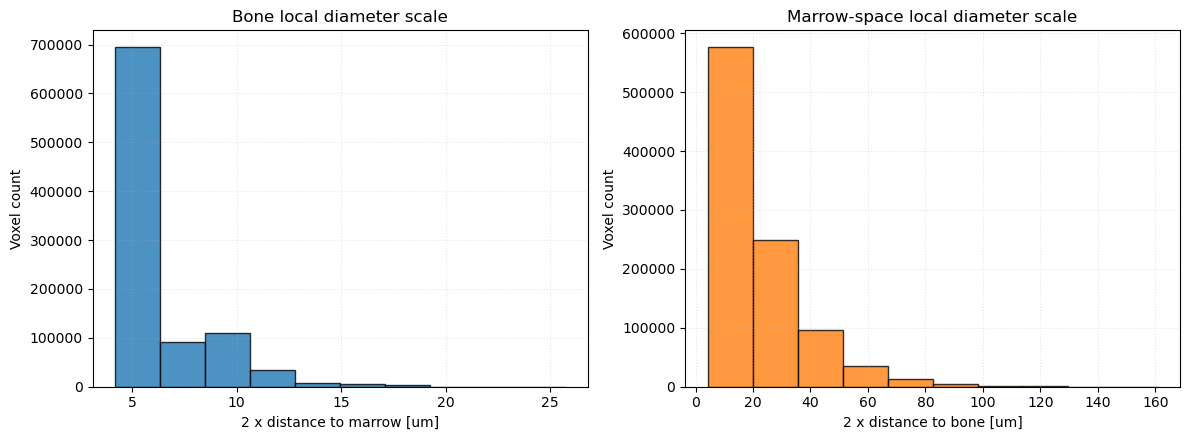

In [14]:
if compute_distance_maps:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].hist(
        2.0 * deterministic_sample(bone_radius_um[bone]),
        color="tab:blue",
        alpha=0.8,
        edgecolor="black",
    )
    axes[0].set_title("Bone local diameter scale")
    axes[0].set_xlabel("2 x distance to marrow [um]")
    axes[0].set_ylabel("Voxel count")
    axes[0].grid(alpha=0.3, linestyle=":")

    axes[1].hist(
        2.0 * deterministic_sample(marrow_radius_um[marrow]),
        color="tab:orange",
        alpha=0.8,
        edgecolor="black",
    )
    axes[1].set_title("Marrow-space local diameter scale")
    axes[1].set_xlabel("2 x distance to bone [um]")
    axes[1].set_ylabel("Voxel count")
    axes[1].grid(alpha=0.3, linestyle=":")

    fig.tight_layout()

## Local thickness and separation

BoneJ-style local thickness assigns each phase voxel the diameter of the
largest sphere that fits inside the phase and contains that voxel. For the
bone phase this gives a `Tb.Th`-style estimate; for the marrow phase it gives
a `Tb.Sp`-style separation estimate. The implementation below uses
`voids.image.local_thickness_analysis`, which wraps PoreSpy's local-thickness
filters and converts their local-radius output into physical diameters.

In [15]:
local_thickness_summary = pd.DataFrame()
local_thickness_paper_comparison = pd.DataFrame()

if compute_local_thickness_maps:
    bone_distance_map_voxels = (
        bone_radius_um / voxel_size_um if compute_distance_maps else None
    )
    marrow_distance_map_voxels = (
        marrow_radius_um / voxel_size_um if compute_distance_maps else None
    )
    bone_local_thickness = local_thickness_analysis(
        bone,
        voxel_size=voxel_size_um,
        units="um",
        label="bone Tb.Th",
        method=local_thickness_method,
        sizes=local_thickness_sizes,
        smooth=local_thickness_smooth,
        approx=local_thickness_approx,
        distance_map=bone_distance_map_voxels,
    )
    marrow_local_thickness = local_thickness_analysis(
        marrow,
        voxel_size=voxel_size_um,
        units="um",
        label="marrow Tb.Sp",
        method=local_thickness_method,
        sizes=local_thickness_sizes,
        smooth=local_thickness_smooth,
        approx=local_thickness_approx,
        distance_map=marrow_distance_map_voxels,
    )

    local_thickness_summary = pd.DataFrame(
        [
            bone_local_thickness.summary.as_dict(),
            marrow_local_thickness.summary.as_dict(),
        ]
    )

    tb_th_local_um = bone_local_thickness.summary.mean
    tb_sp_local_um = marrow_local_thickness.summary.mean
    tb_n_local_per_um = bvtv / tb_th_local_um
    local_thickness_paper_comparison = pd.DataFrame(
        [
            {
                "metric": "BV/TV",
                "crop_estimate": 100.0 * bvtv,
                "crop_units": "%",
                "paper_control_mean": paper_control_bvtv_pct,
                "paper_aluminum_mean": paper_aluminum_bvtv_pct,
                "paper_units": "%",
                "note": "Direct binary volume fraction in cropped cuboid.",
            },
            {
                "metric": "Tb.Th",
                "crop_estimate": tb_th_local_um,
                "crop_units": "um",
                "paper_control_mean": paper_control_tb_th_um,
                "paper_aluminum_mean": paper_aluminum_tb_th_um,
                "paper_units": "um",
                "note": f"Local-thickness diameter map using method={local_thickness_method!r}.",
            },
            {
                "metric": "Tb.Sp",
                "crop_estimate": tb_sp_local_um,
                "crop_units": "um",
                "paper_control_mean": paper_control_tb_sp_um,
                "paper_aluminum_mean": paper_aluminum_tb_sp_um,
                "paper_units": "um",
                "note": "Local-thickness diameter map of the marrow phase.",
            },
            {
                "metric": "Tb.N",
                "crop_estimate": tb_n_local_per_um,
                "crop_units": "1/um",
                "paper_control_mean": paper_control_tb_n_per_um,
                "paper_aluminum_mean": paper_aluminum_tb_n_per_um,
                "paper_units": "1/um",
                "note": "Computed as (BV/TV)/Tb.Th using local thickness.",
            },
        ]
    )

local_thickness_summary

,label,voxel_count,mean,std,p10,p50,p90,max,units,method,voxel_size
0,bone Tb.Th,7582064,9.893896,3.930529,5.628692,9.088844,15.581973,26.713835,um,dt,2.086
1,marrow Tb.Sp,35170436,44.751113,25.527782,19.450539,39.583155,80.554384,163.933592,um,dt,2.086


In [16]:
local_thickness_paper_comparison

,metric,crop_estimate,crop_units,paper_control_mean,paper_aluminum_mean,paper_units,note
0,BV/TV,17.734785,%,24.1000,13.7000,%,Direct binary volume fraction in cropped cuboid.
1,Tb.Th,9.893896,um,19.3000,16.5000,um,Local-thickness diameter map using method='dt'.
2,Tb.Sp,44.751113,um,77.1000,148.3000,um,Local-thickness diameter map of the marrow phase.
3,Tb.N,0.017925,1/um,0.0104,0.0061,1/um,Computed as (BV/TV)/Tb.Th using local thickness.


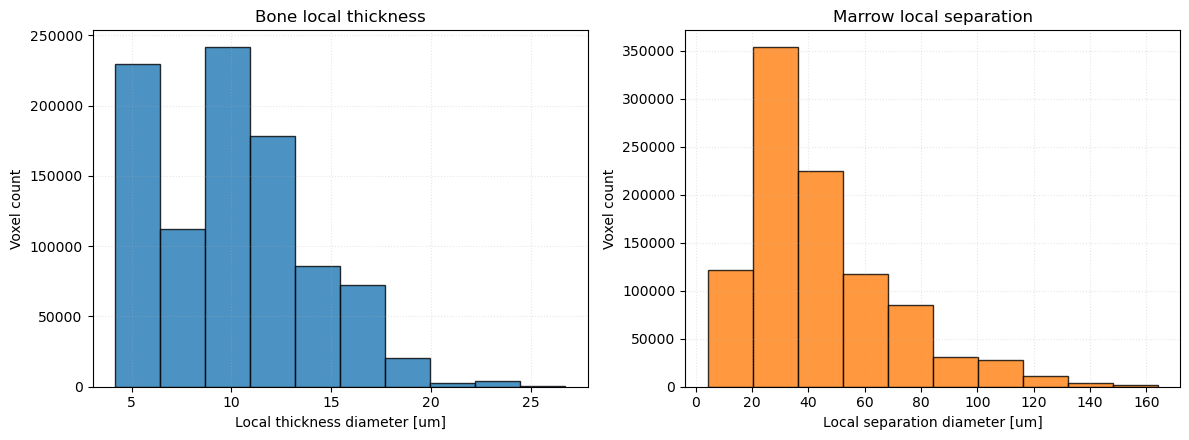

In [17]:
if compute_local_thickness_maps:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].hist(
        deterministic_sample(bone_local_thickness.thickness_map[bone]),
        color="tab:blue",
        alpha=0.8,
        edgecolor="black",
    )
    axes[0].set_title("Bone local thickness")
    axes[0].set_xlabel("Local thickness diameter [um]")
    axes[0].set_ylabel("Voxel count")
    axes[0].grid(alpha=0.3, linestyle=":")

    axes[1].hist(
        deterministic_sample(marrow_local_thickness.thickness_map[marrow]),
        color="tab:orange",
        alpha=0.8,
        edgecolor="black",
    )
    axes[1].set_title("Marrow local separation")
    axes[1].set_xlabel("Local separation diameter [um]")
    axes[1].set_ylabel("Voxel count")
    axes[1].grid(alpha=0.3, linestyle=":")

    fig.tight_layout()

## Component and percolation checks

The component counts below use full 26-neighbor connectivity in 3D. The
percolation flags only say that at least one connected component touches both
opposite ROI faces for the given axis; they do not by themselves prove a
physically meaningful transport boundary condition.

In [18]:
full_connectivity = ndi.generate_binary_structure(rank=3, connectivity=3)


def phase_component_summary(
    mask: np.ndarray,
    *,
    label: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Summarize connected components and axis-spanning labels for one phase."""
    labels, n_components = ndi.label(mask, structure=full_connectivity)
    counts = np.bincount(labels.ravel())
    component_counts = counts[1:]

    if component_counts.size:
        largest_label = int(np.argmax(component_counts) + 1)
        largest_voxels = int(component_counts[largest_label - 1])
        largest_fraction = largest_voxels / int(np.count_nonzero(mask))
    else:
        largest_label = 0
        largest_voxels = 0
        largest_fraction = 0.0

    spans: dict[str, bool] = {}
    for axis, axis_label in enumerate(axis_labels):
        min_slice = [slice(None)] * 3
        max_slice = [slice(None)] * 3
        min_slice[axis] = 0
        max_slice[axis] = labels.shape[axis] - 1
        min_labels = np.unique(labels[tuple(min_slice)])
        max_labels = np.unique(labels[tuple(max_slice)])
        common = np.intersect1d(min_labels, max_labels)
        spans[axis_label] = bool(np.any(common[common != 0]))

    euler = int(measure.euler_number(mask, connectivity=3))

    summary = pd.DataFrame(
        [
            {
                "phase": label,
                "n_components": int(n_components),
                "largest_component_label": largest_label,
                "largest_component_fraction_of_phase": largest_fraction,
                "largest_component_volume_mm3": largest_voxels * voxel_volume_mm3,
                "spans_x": spans["x"],
                "spans_y": spans["y"],
                "spans_z": spans["z"],
                "euler_number_connectivity_26": euler,
                "euler_number_density_1_per_mm3": euler / total_volume_mm3,
            }
        ]
    )

    top = (
        pd.DataFrame(
            {
                "component_label": np.arange(1, component_counts.size + 1),
                "voxel_count": component_counts,
            }
        )
        .sort_values("voxel_count", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    top.insert(0, "phase", label)
    top["volume_mm3"] = top["voxel_count"] * voxel_volume_mm3
    top["fraction_of_phase"] = top["voxel_count"] / int(np.count_nonzero(mask))

    return summary, top


bone_component_summary, bone_top_components = phase_component_summary(
    bone,
    label="bone",
)
marrow_component_summary, marrow_top_components = phase_component_summary(
    marrow,
    label="marrow",
)

component_summary = pd.concat(
    [bone_component_summary, marrow_component_summary],
    ignore_index=True,
)
top_components = pd.concat(
    [bone_top_components, marrow_top_components],
    ignore_index=True,
)

component_summary

,phase,n_components,largest_component_label,largest_component_fraction_of_phase,largest_component_volume_mm3,spans_x,spans_y,spans_z,euler_number_connectivity_26,euler_number_density_1_per_mm3
0,bone,92,1,0.992811,0.068328,True,True,True,-3720,-9586.023999
1,marrow,606,1,0.999752,0.319163,True,True,True,-29995,-77293.760716


In [19]:
top_components

,phase,component_label,voxel_count,volume_mm3,fraction_of_phase
0,bone,1,7527560,6.832775e-02,0.992811
1,bone,5,31455,2.855174e-04,0.004149
2,bone,6,3426,3.109784e-05,0.000452
3,bone,10,3369,3.058045e-05,0.000444
4,bone,13,2882,2.615995e-05,0.000380
5,bone,21,2822,2.561533e-05,0.000372
6,bone,3,2295,2.083174e-05,0.000303
7,bone,61,1713,1.554892e-05,0.000226
8,bone,75,661,5.999905e-06,0.000087
9,bone,63,654,5.936366e-06,0.000086


## Axis-aligned chord lengths

A chord is one continuous run of a phase along a straight line. Axis-aligned
bone chords are a simple trabecular-thickness proxy; axis-aligned marrow
chords are a simple separation proxy. They are not a replacement for a full
mean-intercept-length fabric tensor, but disagreement across `x`, `y`, and
`z` is a useful anisotropy signal.

In [20]:
def line_run_lengths(line: np.ndarray) -> np.ndarray:
    """Return lengths of True-valued runs in a one-dimensional boolean line."""
    padded = np.empty(line.size + 2, dtype=bool)
    padded[0] = False
    padded[1:-1] = line
    padded[-1] = False
    changes = np.flatnonzero(padded[1:] != padded[:-1])
    return changes[1::2] - changes[::2]


def phase_chord_lengths(
    mask: np.ndarray,
    *,
    axis: int,
    line_stride: int,
) -> np.ndarray:
    """Return axis-aligned chord lengths for a phase mask."""
    moved = np.moveaxis(mask, axis, 0)
    n_along_axis = moved.shape[0]
    lines = moved.reshape(n_along_axis, -1).T[::line_stride]
    chunks: list[np.ndarray] = []
    for line in lines:
        lengths = line_run_lengths(line)
        if lengths.size:
            chunks.append(lengths.astype(np.int32, copy=False))
    if not chunks:
        return np.asarray([], dtype=np.int32)
    return np.concatenate(chunks)


chord_records: list[dict[str, float | str]] = []
chord_samples: list[pd.DataFrame] = []
for phase_label, mask in (("bone", bone), ("marrow", marrow)):
    for axis, axis_label in enumerate(axis_labels):
        lengths_vox = phase_chord_lengths(
            mask,
            axis=axis,
            line_stride=chord_line_stride,
        )
        lengths_um = lengths_vox.astype(float) * voxel_size_um
        chord_records.append(
            {
                "phase": phase_label,
                "axis": axis_label,
                "n_chords": float(lengths_um.size),
                "mean_um": float(np.mean(lengths_um)),
                "median_um": float(np.median(lengths_um)),
                "p10_um": float(np.percentile(lengths_um, 10.0)),
                "p90_um": float(np.percentile(lengths_um, 90.0)),
                "max_um": float(np.max(lengths_um)),
            }
        )
        chord_samples.append(
            pd.DataFrame(
                {
                    "phase": phase_label,
                    "axis": axis_label,
                    "length_um": deterministic_sample(lengths_um, max_points=250_000),
                }
            )
        )

chord_summary = pd.DataFrame(chord_records)
chord_lengths = pd.concat(chord_samples, ignore_index=True)
chord_summary

,phase,axis,n_chords,mean_um,median_um,p10_um,p90_um,max_um
0,bone,x,1106740.0,14.290787,10.430,4.172,29.204,177.310
1,bone,y,1589390.0,9.951104,8.344,4.172,18.774,120.988
2,bone,z,1137818.0,13.900453,10.430,4.172,27.118,154.364
3,marrow,x,1197463.0,61.267471,41.720,6.258,137.676,619.542
4,marrow,y,1672936.0,43.854355,33.376,6.258,91.784,506.898
5,marrow,z,1219882.0,60.141497,47.978,10.430,123.074,728.014


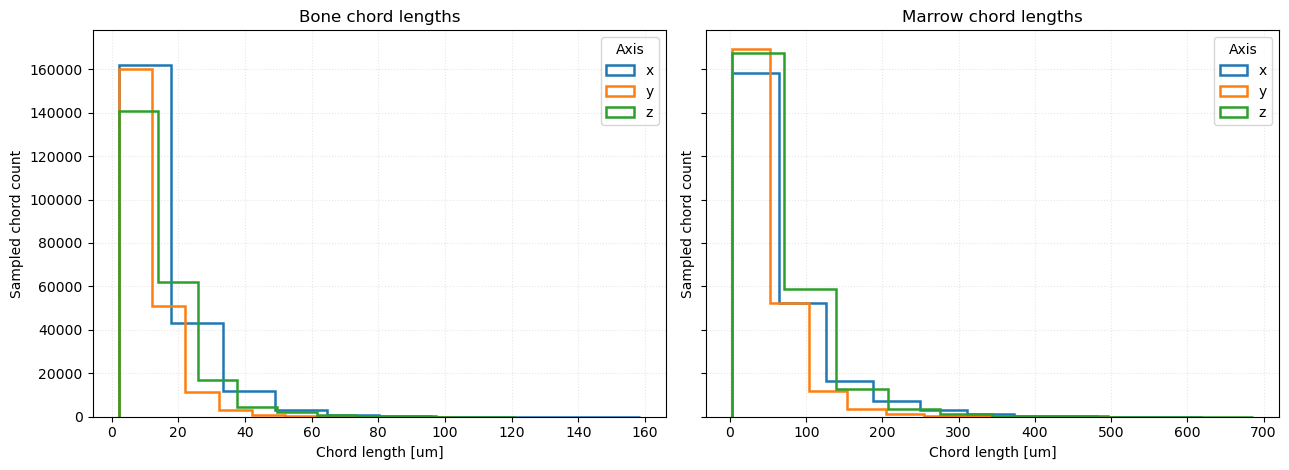

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, phase_label in zip(axes, ("bone", "marrow")):
    for axis_label in axis_labels:
        data = chord_lengths[
            (chord_lengths["phase"] == phase_label)
            & (chord_lengths["axis"] == axis_label)
        ]["length_um"].to_numpy()
        ax.hist(data, histtype="step", linewidth=1.8, label=axis_label)
    ax.set_title(f"{phase_label.capitalize()} chord lengths")
    ax.set_xlabel("Chord length [um]")
    ax.set_ylabel("Sampled chord count")
    ax.grid(alpha=0.3, linestyle=":")
    ax.legend(title="Axis")

fig.tight_layout()

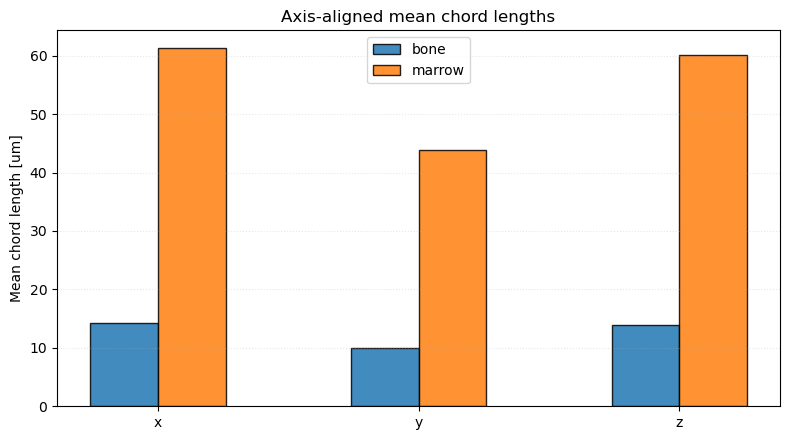

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.26
x = np.arange(len(axis_labels), dtype=float)

for offset, phase_label, color in (
    (-width / 2, "bone", "tab:blue"),
    (width / 2, "marrow", "tab:orange"),
):
    subset = chord_summary[chord_summary["phase"] == phase_label].set_index("axis")
    ax.bar(
        x + offset,
        subset.loc[list(axis_labels), "mean_um"],
        width=width,
        label=phase_label,
        color=color,
        alpha=0.85,
        edgecolor="black",
    )

ax.set_xticks(x)
ax.set_xticklabels(axis_labels)
ax.set_ylabel("Mean chord length [um]")
ax.set_title("Axis-aligned mean chord lengths")
ax.grid(alpha=0.3, linestyle=":", axis="y")
ax.legend()
fig.tight_layout()

## Optional `voids` extension: marrow-space pore network

If `run_marrow_pore_network = True`, the cell below treats marrow/pore space
as the conducting phase and extracts a pore network. That can be interesting
for marrow-fluid transport questions, but the result is a PNM approximation
to the segmented intertrabecular volume, not a mechanical model of bone
stiffness or failure.

In [23]:
if run_marrow_pore_network:
    import porespy as ps

    from voids.geom import characteristic_size
    from voids.graph.metrics import connectivity_metrics, coordination_numbers
    from voids.image import extract_spanning_pore_network

    pnm_records: list[dict[str, float | str]] = []
    for axis_label in axis_labels:
        axis_index = axis_labels.index(axis_label)
        axis_marrow = ps.filters.trim_nonpercolating_paths(
            marrow,
            axis=axis_index,
        ).astype(np.int8)
        extract = extract_spanning_pore_network(
            axis_marrow,
            voxel_size=voxel_size_mm,
            flow_axis=axis_label,
            length_unit="mm",
            geometry_repairs=None,
            provenance_notes={
                "raw_source": str(raw_relpath).replace("\\", "/"),
                "raw_shape_voxels": raw_shape,
                "phase_convention": "marrow/pore = 0, bone = 1",
                "analysis_note": "Marrow phase treated as void space for PNM extraction.",
            },
        )
        net = extract.net
        pore_size, pore_size_field = characteristic_size(
            net.pore, expected_shape=(net.Np,)
        )
        throat_size, throat_size_field = characteristic_size(
            net.throat,
            expected_shape=(net.Nt,),
        )
        coord = coordination_numbers(net)
        conn = connectivity_metrics(net)
        pnm_records.append(
            {
                "axis": axis_label,
                "pores": float(net.Np),
                "throats": float(net.Nt),
                "mean_coordination": float(np.mean(coord)),
                f"mean_pore_{pore_size_field}_um": float(1.0e3 * np.mean(pore_size)),
                f"mean_throat_{throat_size_field}_um": float(
                    1.0e3 * np.mean(throat_size)
                ),
                "giant_component_fraction": float(conn.giant_component_fraction),
            }
        )

    marrow_pnm_summary = pd.DataFrame(pnm_records)
    marrow_pnm_summary

## Scientific caveats

- The RAW file has no sidecar metadata. The shape `(350, 350, 349)`,
  `C`-order storage, and axis labels should be checked against the acquisition
  or export provenance before directional conclusions are used in a paper.
- The filename is the only provenance currently used for the phase convention
  and exact voxel size. The source paper reports about `2 um/voxel` for the
  trabecular micro-CT analysis, while the local filename indicates `2086 nm`.
  If a scanner/export log exists, use it to confirm `0 = pore/marrow`,
  `1 = bone`, and `2086 nm`.
- This cropped cuboid is about 6% of the published cylindrical trabecular VOI.
  It should not be used as a one-to-one reproduction of the paper's Table 1
  averages or group conclusions.
- `BV/TV` and component/percolation checks are direct consequences of the
  binary segmentation. Thickness, separation, and chord-length summaries are
  morphology estimators and can change with thresholding, resolution, and ROI
  boundary handling.
- The surface-based `Tb.Th`, `Tb.N`, and `Tb.Sp` are plate-model proxies.
  They are useful for a compact first pass, but the local-thickness table is
  the closer comparison to the paper's BoneJ-style workflow.
- The default local-thickness method in this notebook is the practical PoreSpy
  distance-transform/opening method with finite radius sampling. Use
  `local_thickness_method = "imj"` for a closer ImageJ-style sphere-insertion
  workflow, accepting a substantially longer runtime.
- Optional PNM extraction analyzes the marrow-space pore geometry and possible
  fluid transport. It is not a substitute for finite-element stiffness,
  mineral density, or tissue-level mechanical analysis of trabecular bone.